In [33]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits

In [34]:
flux = fits.open('n0044_HIP55192_ts23_2020may20_spectrum.fits')[0].data

In [35]:
flux

array([[        nan,         nan,  114.526276, ...,  125.07718 ,
         198.79655 ,  210.98343 ],
       [        nan,         nan,  -79.04178 , ...,  577.43225 ,
         537.9837  ,  802.60254 ],
       [        nan,         nan, -164.46208 , ..., 1825.0328  ,
        1409.8431  , 1315.1622  ],
       ...,
       [        nan,         nan, 4384.28    , ..., 3774.2747  ,
        3874.3083  , 4266.3037  ],
       [        nan,         nan, 1921.707   , ..., 1440.1074  ,
        1544.5939  , 1828.9744  ],
       [        nan,         nan,  438.2027  , ...,  201.95378 ,
         -18.880178,  277.6779  ]], shape=(56, 2048), dtype='>f4')

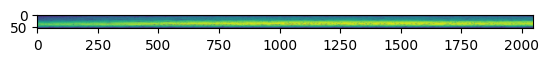

In [36]:
plt.imshow(flux)

In [37]:
wave = fits.open('ts23_2020may20_thar_solution_wavearr.fits')[0].data

In [38]:
wave

array([[ 3867.84817082,  3867.88185344,  3867.91529198, ...,
         3932.85730656,  3932.88732801,  3932.91710537],
       [ 3912.34460394,  3912.37853062,  3912.41270137, ...,
         3978.18577424,  3978.21603975,  3978.24654933],
       [ 3957.95718413,  3957.99135487,  3958.02552562, ...,
         4024.33115095,  4024.3619046 ,  4024.39265826],
       ...,
       [ 9723.72110863,  9723.80409386,  9723.8870791 , ...,
         9887.40313939,  9887.47929054,  9887.5554417 ],
       [10009.6228123 , 10009.70872642, 10009.79464054, ...,
        10179.22606895, 10179.30612528, 10179.38520532],
       [10312.8742613 , 10312.96310431, 10313.05194731, ...,
        10485.58505626, 10485.6641363 , 10485.74321633]],
      shape=(56, 2048), dtype='>f8')

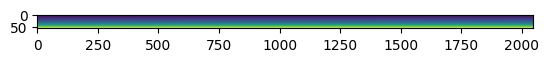

In [39]:
plt.imshow(wave)

<function matplotlib.pyplot.show(close=None, block=None)>

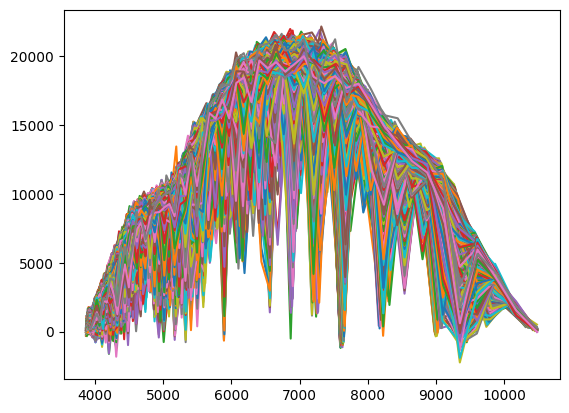

In [40]:
plt.plot(wave, flux)
plt.show

In [41]:
from scipy.optimize import curve_fit

In [42]:
def find_order(wave, target=6707.819):
    return np.argmin([np.min(np.abs(order - target)) for order in wave])

order_idx = find_order(wave)
w = wave[order_idx]
f = flux[order_idx]

In [43]:
mask = (w > 6704) & (w < 6710)
w, f = w[mask], f[mask]

In [44]:
coeffs = np.polyfit(w, f, 1)
continuum = np.polyval(coeffs, w)
f_norm = f / continuum

In [45]:
import emcee

def gaussian(x, amp, mu, sigma):
    return 1 - amp * np.exp(-(x - mu)**2 / (2 * sigma**2))

yerr = np.std(f_norm - np.median(f_norm))

def log_likelihood(theta, x, y, yerr):
    amp, mu, sigma = theta
    model = gaussian(x, amp, mu, sigma)
    return -0.5 * np.sum(((y - model) / yerr)**2 + np.log(2*np.pi*yerr**2))

In [46]:
def log_prior(theta):
    amp, mu, sigma = theta
    
    if 0.0 < amp < 1.0 and 6707.0 < mu < 6708.5 and 0.01 < sigma < 0.50:
        return 0.0
    
    return -np.inf

In [47]:
def log_probability(theta, x, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y, yerr)

In [51]:
ndim = 3
nwalkers = 1000

initial = np.array([0.2, 6707.819, 0.2])   
pos = initial + 1e-3 * np.random.randn(nwalkers, ndim)

In [52]:
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(w, f_norm, yerr))

sampler.run_mcmc(pos, 4000, progress=True)

100%|██████████████████████████████████████████████████████████████████████████████| 4000/4000 [02:21<00:00, 28.36it/s]


State([[2.87954016e-01 6.70822841e+03 1.38607102e-01]
 [3.44635886e-01 6.70825292e+03 9.74334746e-02]
 [2.99644987e-01 6.70825785e+03 9.75481589e-02]
 ...
 [2.31337540e-01 6.70818238e+03 1.36762935e-01]
 [2.85576429e-01 6.70824593e+03 1.51929612e-01]
 [2.79136047e-01 6.70820069e+03 6.92885324e-02]], log_prob=[147.88954123 147.9860484  147.58578383 144.4403136  145.76149974
 148.18310925 148.96948079 147.73731877 148.01260723 148.30240698
 148.96688545 148.12762755 142.84527058 147.63231062 148.81612413
 147.81644866 148.09919825 148.80167364 146.70564963 147.58430892
 146.94537052 148.93062134 147.87134256 147.60625092 148.07084689
 146.39985025 148.02601626 149.05132546 148.06024912 148.29768012
 144.49725031 147.49387845 148.57309508 148.36190665 147.644456
 147.28937952 145.59554079 147.9731638  149.05849078 148.99909424
 147.87289023 146.69231886 148.71233475 148.41953791 148.93698233
 145.94705843 146.78695165 148.89354536 148.22639711 148.41988268
 148.16365476 148.84029956 146.8

In [53]:
samples = sampler.get_chain(discard=1000, thin=15, flat=True)

In [54]:
amp_mcmc, mu_mcmc, sigma_mcmc = np.percentile(samples, 50, axis=0)

amp_lo, mu_lo, sigma_lo = np.percentile(samples, 16, axis=0)
amp_hi, mu_hi, sigma_hi = np.percentile(samples, 84, axis=0)

In [55]:
EW_samples = np.sqrt(2*np.pi) * samples[:,0] * samples[:,2] * 1000

EW = np.median(EW_samples)
EW_low = EW - np.percentile(EW_samples, 16)
EW_high = np.percentile(EW_samples, 84) - EW

print(f"Amp   = {amp_mcmc:.4f}")
print(f"Mu    = {mu_mcmc:.4f}")
print(f"Sigma = {sigma_mcmc:.4f}")
print(f"EW = {EW:.2f} (+{EW_high:.2f}/-{EW_low:.2f}) mÅ")

Amp   = 0.3084
Mu    = 6708.2249
Sigma = 0.1086
EW = 83.73 (+14.19/-13.56) mÅ


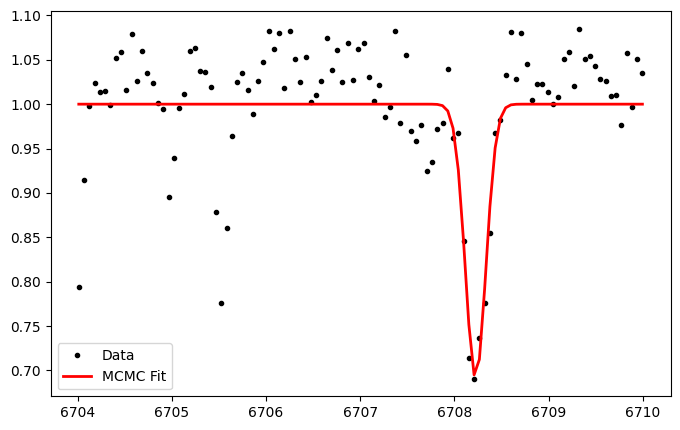

In [56]:
plt.figure(figsize=(8,5))
plt.plot(w, f_norm, 'k.', label='Data')
plt.plot(w, gaussian(w, amp_mcmc, mu_mcmc, sigma_mcmc),
         'r-', lw=2, label='MCMC Fit')
plt.legend()
plt.show()